## **HEALTHCONNECT CLINIC PROJECT CONTINUATION WEEK 5**

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PHASE 1: DATA LOADING



In [79]:
# Load the dataset
df = pd.read_csv('HealthConnect_Appointment_Data.csv')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully.
Shape: 5000 rows and 18 columns.


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


# PHASE 2: DATA PREPARATION AND QUALITY CHECKS

In [80]:
# 1. Convert dates (The CSV uses M/D/YYYY format)
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y', errors='coerce')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y', errors='coerce')

# 2. Clean 'reminder_channel' (Change string 'None' to actual NaN for accuracy)
df['reminder_channel'] = df['reminder_channel'].replace('None', np.nan)

# 3. Create Target Flag (1 = No-Show, 0 = Attended/Cancelled)
df['is_noshow'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# 4. Create Bands for Analysis
df['lead_band'] = pd.cut(df['booking_lead_days'], bins=[-1, 7, 14, 30, 60], labels=['0-7 days', '8-14 days', '15-30 days', '31-60 days'])
df['dist_band'] = pd.cut(df['distance_to_clinic_km'], bins=[-1, 10, 20, 30, 100], labels=['0-10km', '10-20km', '20-30km', '30+km'])
df['history_band'] = pd.cut(df['previous_no_shows'], bins=[-1, 0, 1, 10], labels=['0 (Clean)', '1 past', '2+ past'])

# 5. Quality Checks Printout
print("=== DATA QUALITY CHECKS ===")
print(f"Missing distance values: {df['distance_to_clinic_km'].isnull().sum()}")
print(f"Missing waiting time values: {df['waiting_time_minutes'].isnull().sum()}")
print(f"Duplicate Appointment IDs: {df['appointment_id'].duplicated().sum()}")
print(f"Logic check (prev_no_shows > prev_appointments): {(df['previous_no_shows'] > df['previous_appointments']).sum()}")

# Save cleaned version (Do not overwrite original)
df.to_csv('HealthConnect_Cleaned_Data.csv', index=False)
print("\nCleaned dataset saved as 'HealthConnect_Cleaned_Data.csv'.")

=== DATA QUALITY CHECKS ===
Missing distance values: 90
Missing waiting time values: 60
Duplicate Appointment IDs: 0
Logic check (prev_no_shows > prev_appointments): 0

Cleaned dataset saved as 'HealthConnect_Cleaned_Data.csv'.


# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

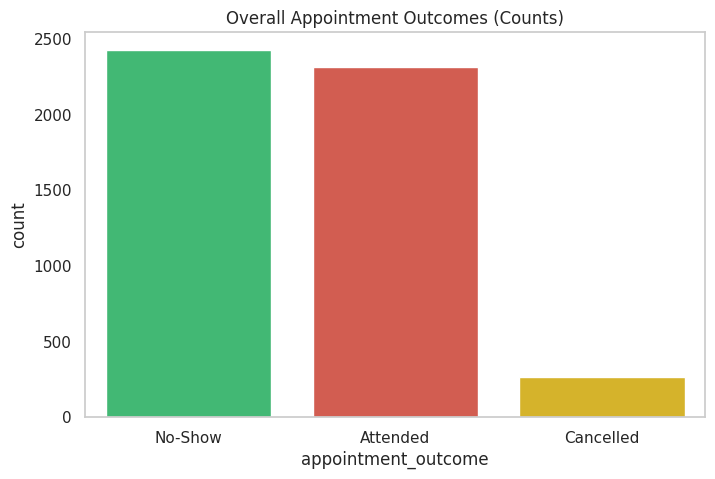

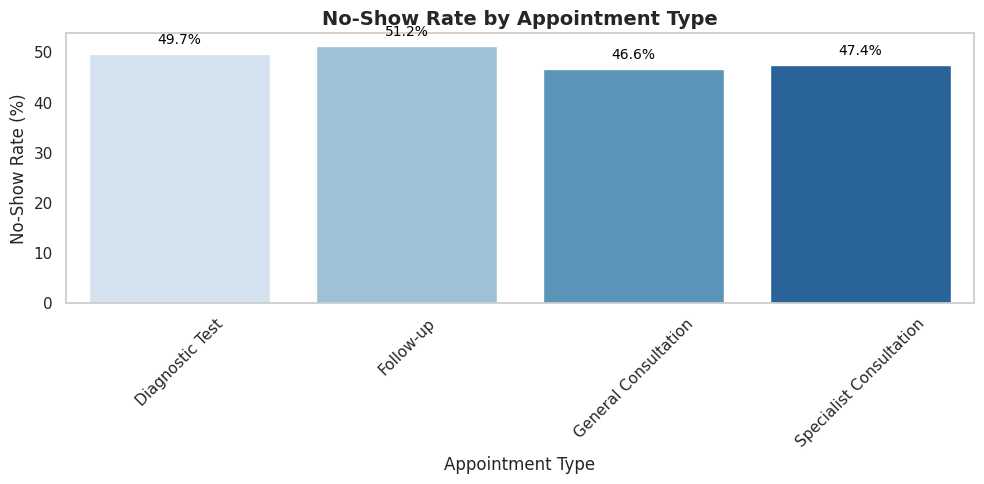

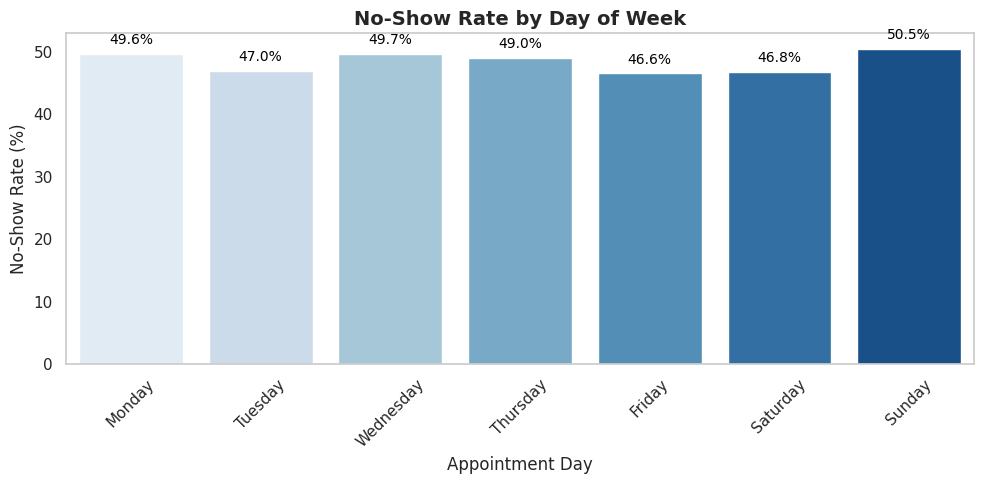

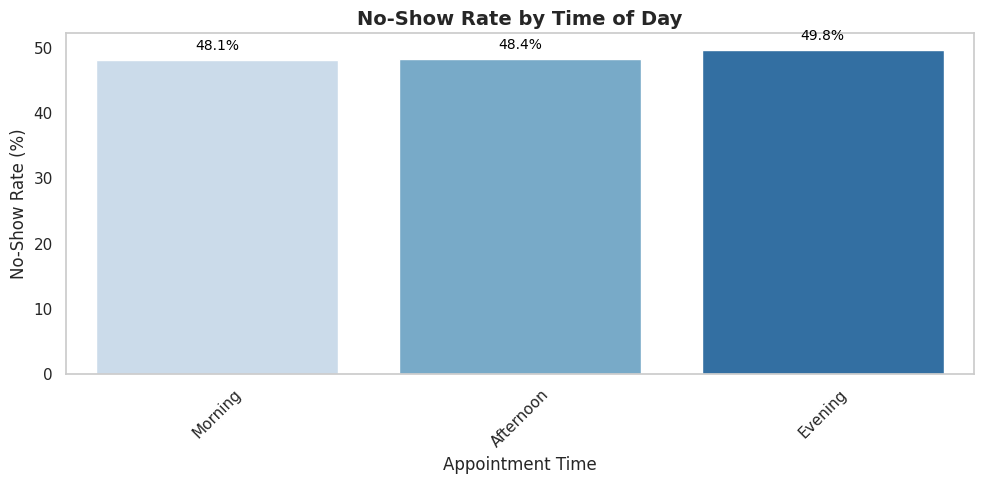

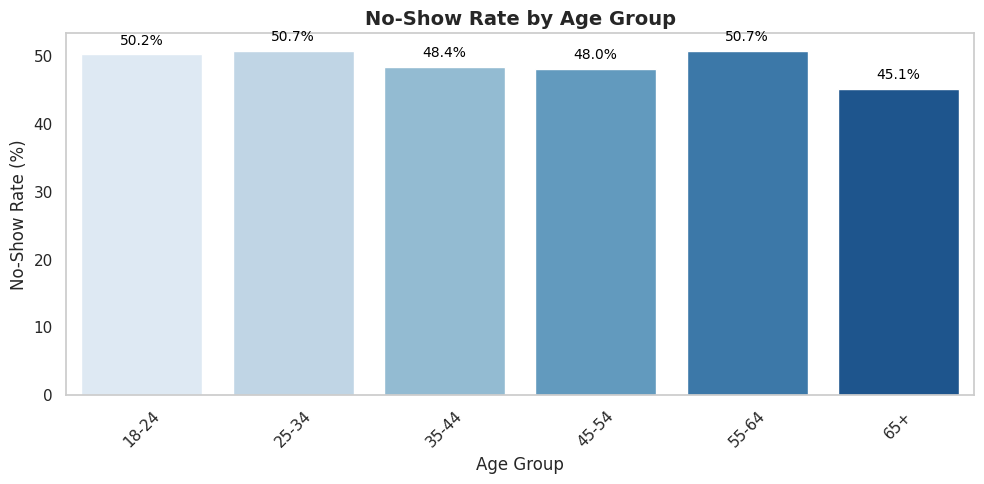

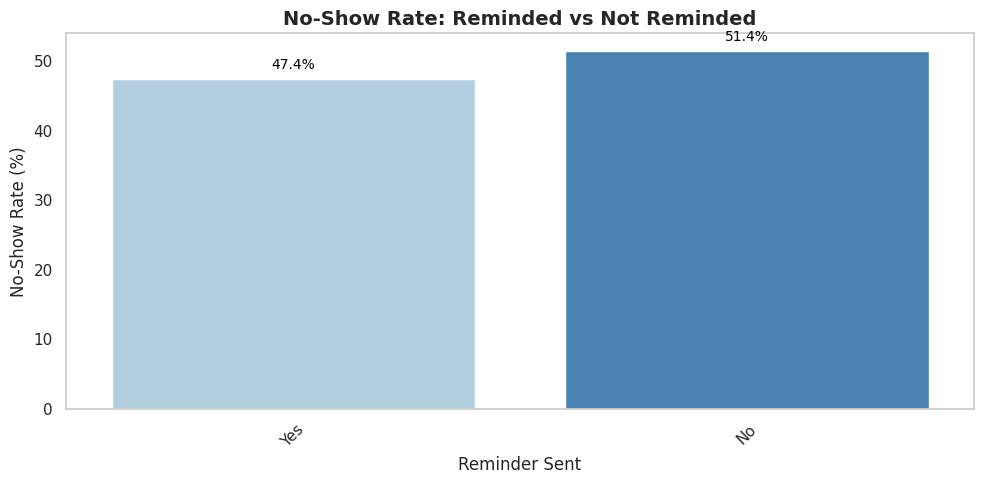

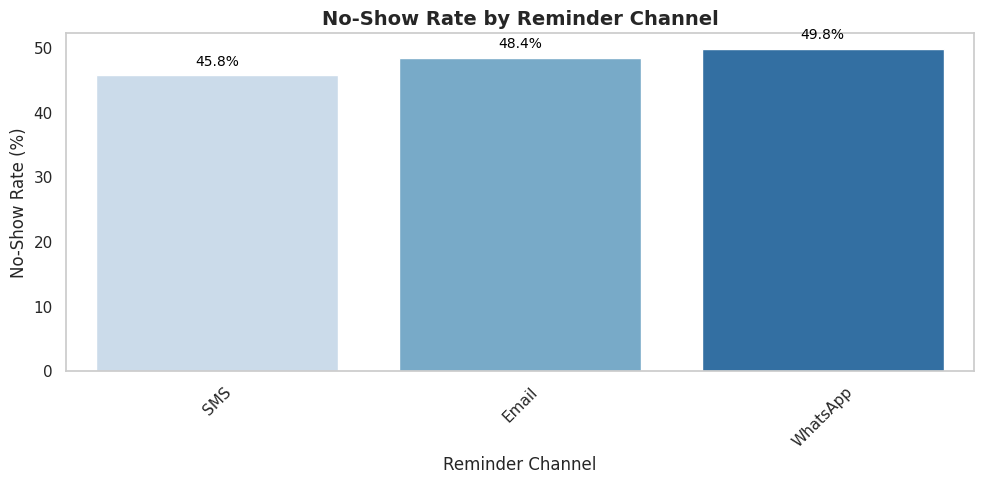

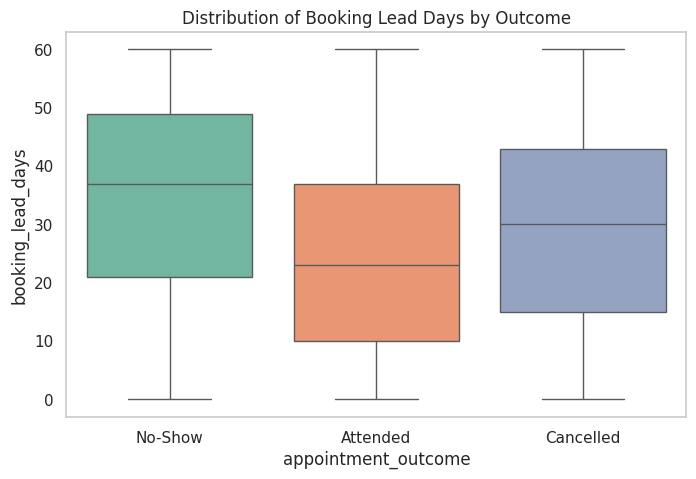

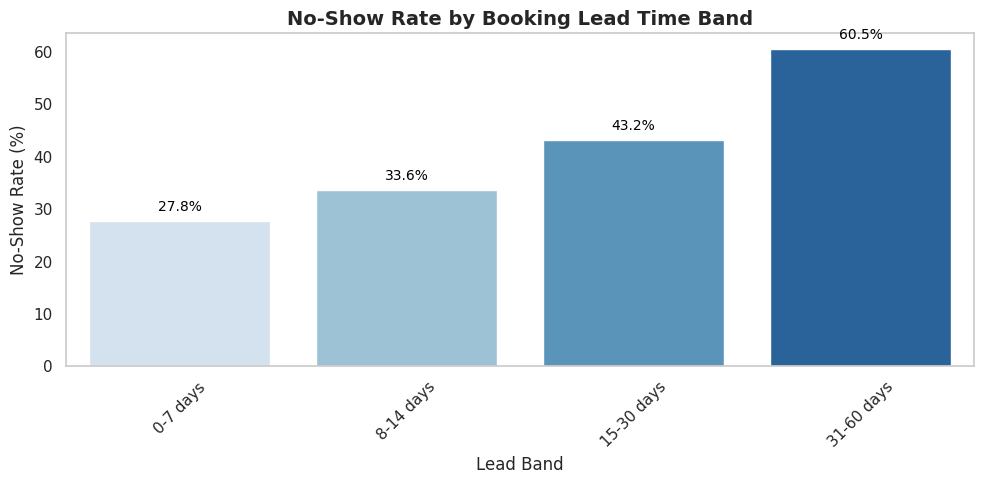

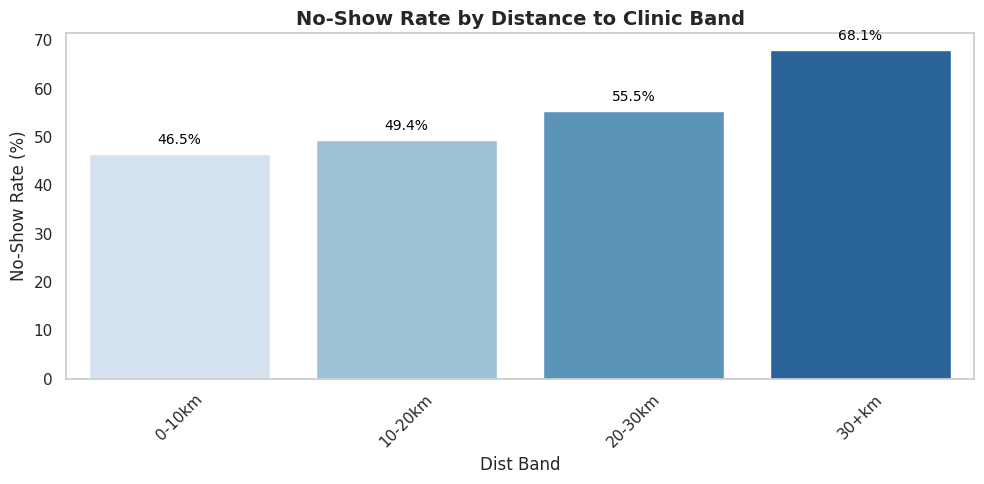

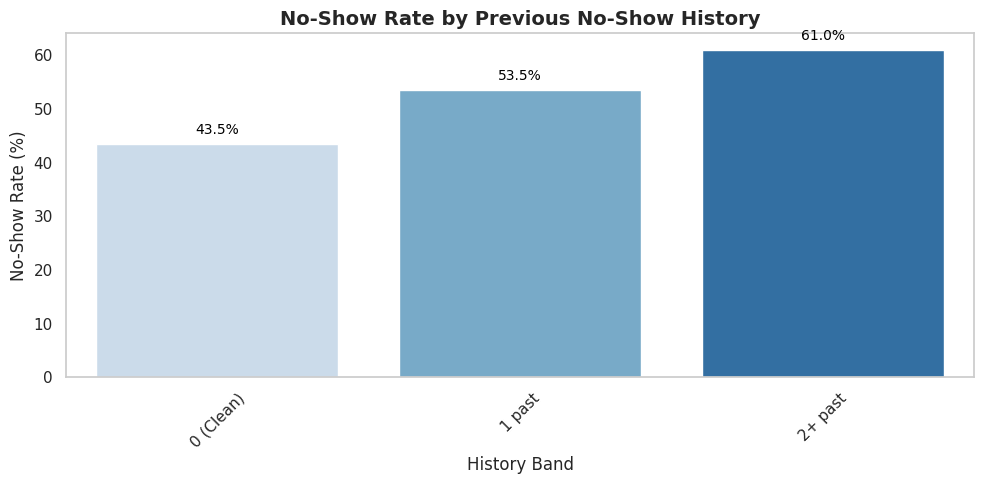

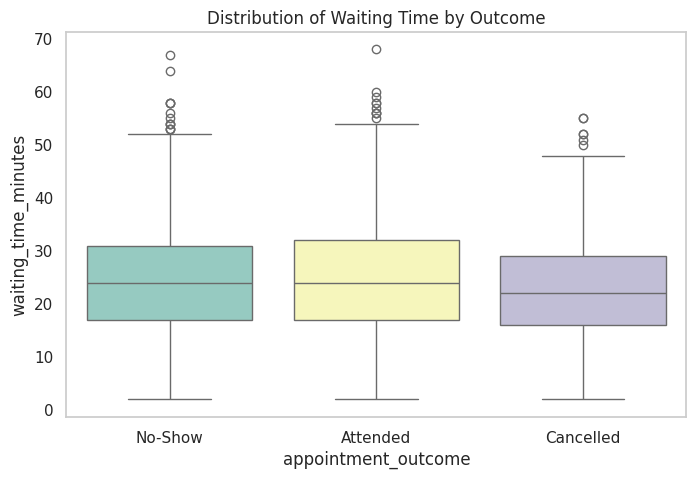

In [81]:
# Helper function to easily plot No-Show rates
def plot_noshow_rate(column, title, order=None, palette='Blues', filename_prefix=None):
    plt.figure(figsize=(10, 5))
    rates = df.groupby(column, observed=True)['is_noshow'].mean() * 100
    if order: rates = rates.reindex(order)
    sns.barplot(x=rates.index, y=rates.values, hue=rates.index, palette=palette, legend=False)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('No-Show Rate (%)')
    plt.xlabel(column.replace('_', ' ').title())
    plt.xticks(rotation=45)
    for p in plt.gca().patches:
        plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.grid(False)
    plt.tight_layout()
    plt.show() # Display the figure

# 1. Outcome Mix (Counts)
plt.figure(figsize=(8, 5))
sns.countplot(x='appointment_outcome', data=df, hue='appointment_outcome', palette=['#2ecc71', '#e74c3c', '#f1c40f'], legend=False)
plt.title('Overall Appointment Outcomes (Counts)')
plt.grid(False)
plt.show() # Display the figure

# 2 to 7: No-Show Rates by Categorical Variables
plot_noshow_rate('appointment_type', 'No-Show Rate by Appointment Type')
plot_noshow_rate('appointment_day', 'No-Show Rate by Day of Week',
                 order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plot_noshow_rate('appointment_time', 'No-Show Rate by Time of Day', order=['Morning', 'Afternoon', 'Evening'])
plot_noshow_rate('age_group', 'No-Show Rate by Age Group',
                 order=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
plot_noshow_rate('reminder_sent', 'No-Show Rate: Reminded vs Not Reminded', order=['Yes', 'No'])
plot_noshow_rate('reminder_channel', 'No-Show Rate by Reminder Channel', order=['SMS', 'Email', 'WhatsApp'])

# 8. Booking Lead Days Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='appointment_outcome', y='booking_lead_days', data=df, hue='appointment_outcome', palette='Set2', legend=False)
plt.title('Distribution of Booking Lead Days by Outcome')
plt.grid(False)
plt.show() # Display the figure

# 9 to 11: No-Show Rates by Banded Variables
plot_noshow_rate('lead_band', 'No-Show Rate by Booking Lead Time Band')
plot_noshow_rate('dist_band', 'No-Show Rate by Distance to Clinic Band')
plot_noshow_rate('history_band', 'No-Show Rate by Previous No-Show History')

# 12. Waiting Time Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='appointment_outcome', y='waiting_time_minutes', data=df, hue='appointment_outcome', palette='Set3', legend=False)
plt.title('Distribution of Waiting Time by Outcome')
plt.grid(False)
plt.show() # Display the figure

# PHASE 4: KPI CALCULATIONS

In [82]:
# KPI 1: Overall No-Show Rate
total_appts = len(df)
total_noshows = df['is_noshow'].sum()
kpi1 = (total_noshows / total_appts) * 100
print(f"KPI 1 - Overall No-Show Rate: {kpi1:.1f}%")
print("   -> Meaning: Nearly half of all booked slots are wasted.\n")

# KPI 2: Reminder Effectiveness
rem_yes = df[df['reminder_sent'] == 'Yes']['is_noshow'].mean() * 100
rem_no = df[df['reminder_sent'] == 'No']['is_noshow'].mean() * 100
print(f"KPI 2 - Reminder Effectiveness:")
print(f"   -> No-Show Rate WITH Reminder: {rem_yes:.1f}%")
print(f"   -> No-Show Rate WITHOUT Reminder: {rem_no:.1f}%")
print(f"   -> Meaning: Reminders reduce no-shows by about {rem_no - rem_yes:.1f} percentage points.\n")

# KPI 3: Average Advance Booking Risk (Lead Time)
lead_ns = df[df['is_noshow'] == 1]['booking_lead_days'].mean()
lead_att = df[df['appointment_outcome'] == 'Attended']['booking_lead_days'].mean()
print(f"KPI 3 - Average Booking Lead Time:")
print(f"   -> For No-Shows: {lead_ns:.1f} days")
print(f"   -> For Attended: {lead_att:.1f} days")
print("   -> Meaning: Patients who book further in advance are much more likely to forget and miss their appointment.\n")

# KPI 4: Repeat No-Show Risk
rep_ns = df[df['previous_no_shows'] > 0]['is_noshow'].mean() * 100
clean_ns = df[df['previous_no_shows'] == 0]['is_noshow'].mean() * 100
print(f"KPI 4 - Repeat No-Show Rate:")
print(f"   -> Patients with past no-shows: {rep_ns:.1f}%")
print(f"   -> Patients with clean history: {clean_ns:.1f}%")
print("   -> Meaning: Past behavior is a strong predictor of future no-shows.\n")

# KPI 5: Distance Barrier
print("KPI 5 - No-Show Rate by Distance Band:")
dist_rates = df.groupby('dist_band', observed=True)['is_noshow'].mean() * 100
for band, rate in dist_rates.items():
    print(f"   -> {band}: {rate:.1f}%")
print("=== KEY PERFORMANCE INDICATORS (KPIs) ===\n")
print("   -> Meaning: Travel friction significantly increases the likelihood of a missed appointment.\n")

KPI 1 - Overall No-Show Rate: 48.5%
   -> Meaning: Nearly half of all booked slots are wasted.

KPI 2 - Reminder Effectiveness:
   -> No-Show Rate WITH Reminder: 47.4%
   -> No-Show Rate WITHOUT Reminder: 51.4%
   -> Meaning: Reminders reduce no-shows by about 4.0 percentage points.

KPI 3 - Average Booking Lead Time:
   -> For No-Shows: 34.5 days
   -> For Attended: 24.5 days
   -> Meaning: Patients who book further in advance are much more likely to forget and miss their appointment.

KPI 4 - Repeat No-Show Rate:
   -> Patients with past no-shows: 55.4%
   -> Patients with clean history: 43.5%
   -> Meaning: Past behavior is a strong predictor of future no-shows.

KPI 5 - No-Show Rate by Distance Band:
   -> 0-10km: 46.5%
   -> 10-20km: 49.4%
   -> 20-30km: 55.5%
   -> 30+km: 68.1%
=== KEY PERFORMANCE INDICATORS (KPIs) ===

   -> Meaning: Travel friction significantly increases the likelihood of a missed appointment.



# PHASE 5: DATA VISUALIZATION

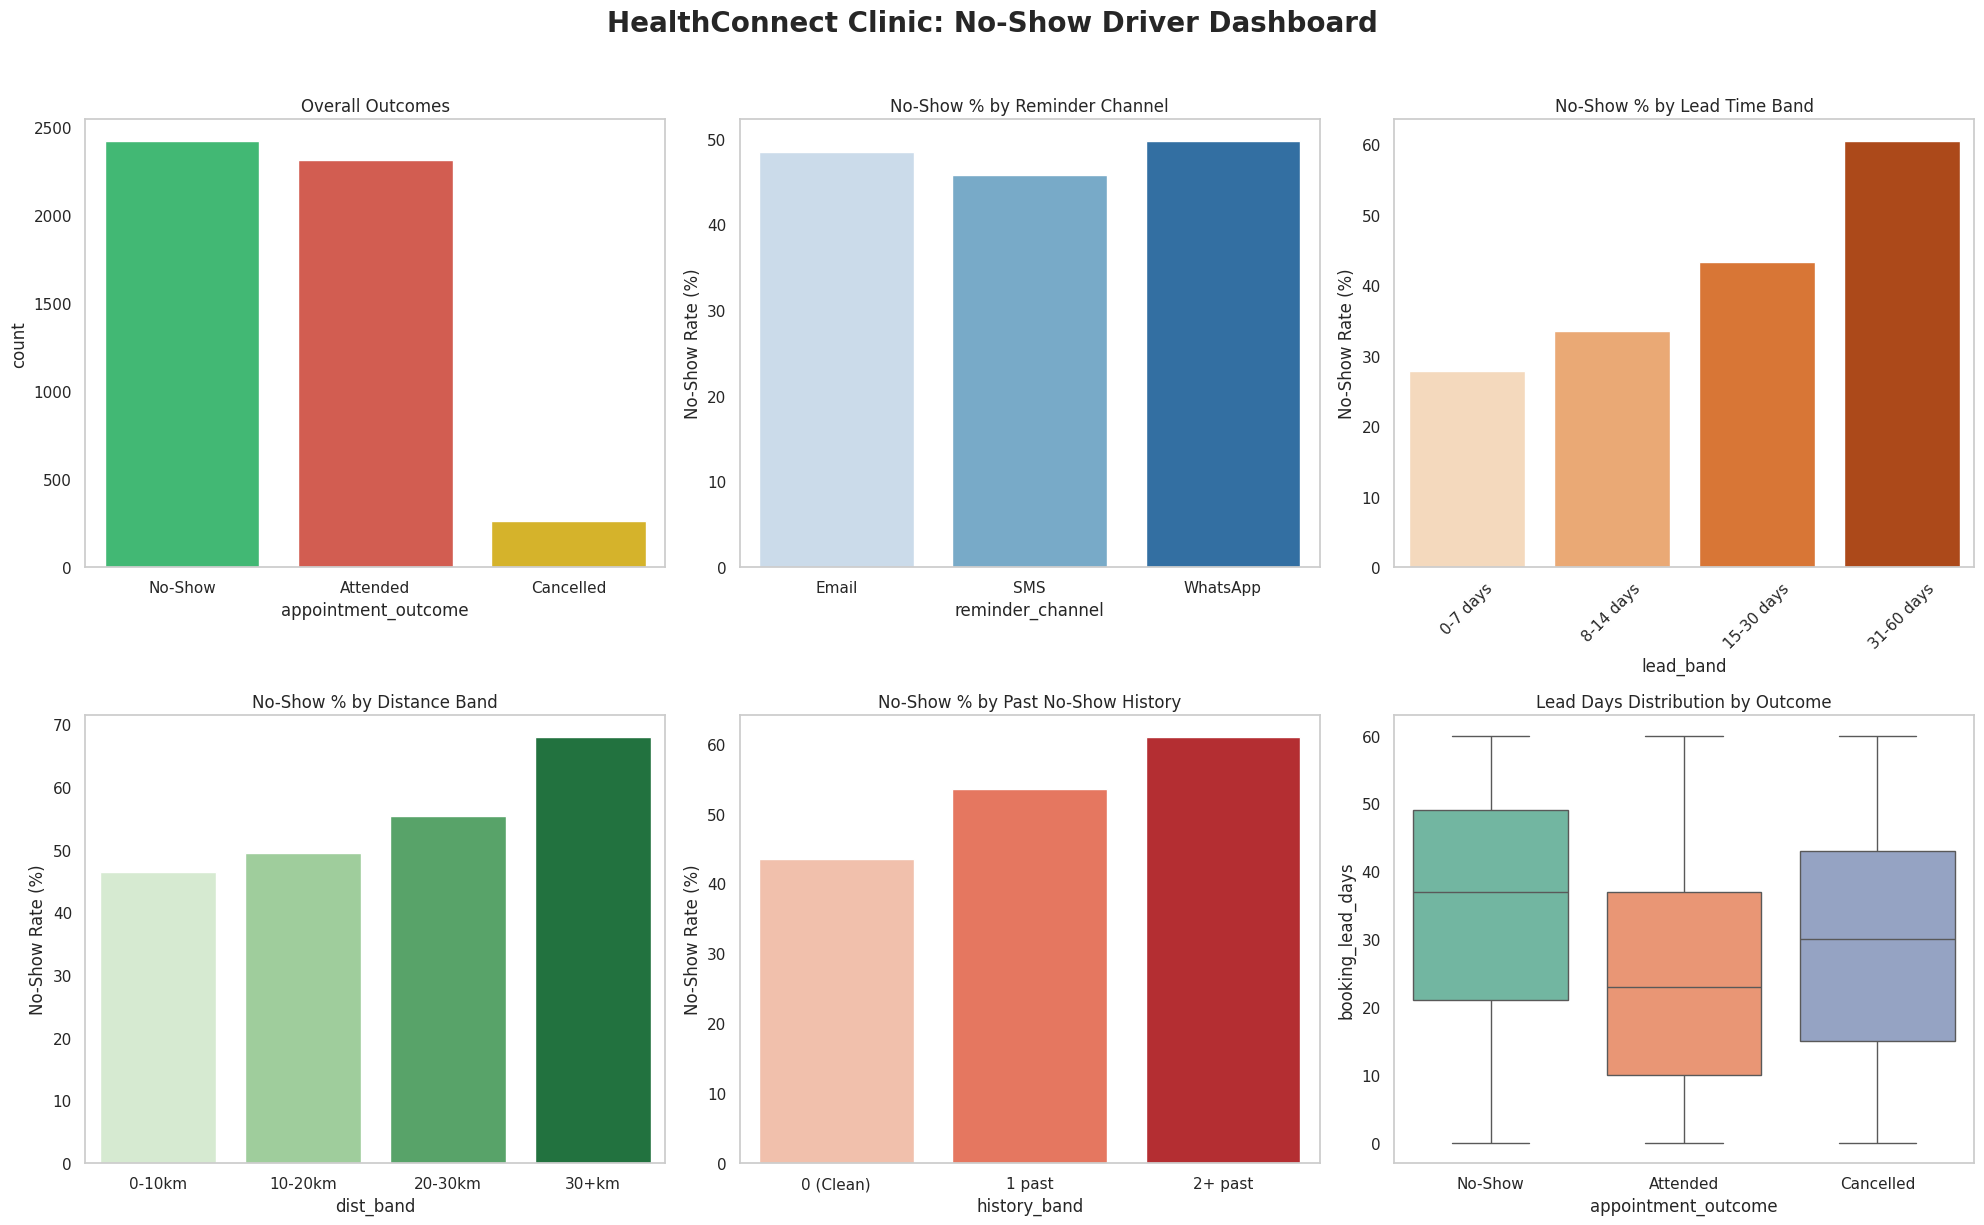

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('HealthConnect Clinic: No-Show Driver Dashboard', fontsize=20, fontweight='bold', y=1.02)

# 1. Outcome Mix
sns.countplot(x='appointment_outcome', data=df, ax=axes[0,0], hue='appointment_outcome', palette=['#2ecc71', '#e74c3c', '#f1c40f'], legend=False)
axes[0,0].set_title('Overall Outcomes')

# 2. Reminder Channel
ch_rates = df.groupby('reminder_channel', observed=True)['is_noshow'].mean() * 100
sns.barplot(x=ch_rates.index, y=ch_rates.values, ax=axes[0,1], hue=ch_rates.index, palette='Blues', legend=False)
axes[0,1].set_title('No-Show % by Reminder Channel')
axes[0,1].set_ylabel('No-Show Rate (%)')

# 3. Lead Time Band
lead_rates = df.groupby('lead_band', observed=True)['is_noshow'].mean() * 100
sns.barplot(x=lead_rates.index, y=lead_rates.values, ax=axes[0,2], hue=lead_rates.index, palette='Oranges', legend=False)
axes[0,2].set_title('No-Show % by Lead Time Band')
axes[0,2].set_ylabel('No-Show Rate (%)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Distance Band
dist_rates = df.groupby('dist_band', observed=True)['is_noshow'].mean() * 100
sns.barplot(x=dist_rates.index, y=dist_rates.values, ax=axes[1,0], hue=dist_rates.index, palette='Greens', legend=False)
axes[1,0].set_title('No-Show % by Distance Band')
axes[1,0].set_ylabel('No-Show Rate (%)')

# 5. Previous History
hist_rates = df.groupby('history_band', observed=True)['is_noshow'].mean() * 100
sns.barplot(x=hist_rates.index, y=hist_rates.values, ax=axes[1,1], hue=hist_rates.index, palette='Reds', legend=False)
axes[1,1].set_title('No-Show % by Past No-Show History')
axes[1,1].set_ylabel('No-Show Rate (%)')

# 6. Lead Days Boxplot
sns.boxplot(x='appointment_outcome', y='booking_lead_days', data=df, ax=axes[1,2], hue='appointment_outcome', palette='Set2', legend=False)
axes[1,2].set_title('Lead Days Distribution by Outcome')

for ax_row in axes:
    for ax in ax_row:
        ax.grid(False)

plt.tight_layout()
plt.show() # Display the figure